# Body Performance: Complete Machine Learning Project
**Dataset:** `bodyPerformance.csv` | **Date:** March 2026

1. **Part 1** - Data Preparation & EDA
2. **Part 2** - Machine Learning Model Training
3. **Part 3** - Performance Evaluation & Model Comparison




 Imports and Setup




In [ ]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,
    mean_squared_error, r2_score)
import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DATA_PATH = "/content/bodyPerformance.csv"


---
# Part 1: Data Preparation and EDA

## 1.1 Dataset Overview

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum()/1024:.1f} KB")
df.head()

Shape: 13,393 rows x 12 columns
Memory: 2354.4 KB


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


 1.2 Data Type Verification

In [ ]:

print(" Data Types:\n")
print(df.dtypes, "\n")
df.columns = df.columns.str.strip()

# Unique values for categorical columns
print("Unique Values:\n")

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")
print()

# Target variable analysis
print(" Target Variable (class):")
print("Unique values:", sorted(df['class'].unique()))
print("Counts:\n", df['class'].value_counts(), "\n")

# Data type note
print(" Note:")
print("Some columns like 'age' and 'sit-ups_counts' are float64 but contain integer-like values.")
print("This is acceptable for Machine Learning models.\n")

 Data Types:

age                        float64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object 

Unique Values:

gender: ['M' 'F']
class: ['C' 'A' 'B' 'D']

 Target Variable (class):
Unique values: ['A', 'B', 'C', 'D']
Counts:
 class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64 

 Note:
Some columns like 'age' and 'sit-ups_counts' are float64 but contain integer-like values.
This is acceptable for Machine Learning models.




**1.3 Missing Values**

In [ ]:
miss = pd.DataFrame({
    'Count': df.isnull().sum(),
    'Pct %': (df.isnull().sum()/len(df)*100).round(2)
})

print(miss)

print("Result: No missing values. No imputation required.")

                         Count  Pct %
age                          0    0.0
gender                       0    0.0
height_cm                    0    0.0
weight_kg                    0    0.0
body fat_%                   0    0.0
diastolic                    0    0.0
systolic                     0    0.0
gripForce                    0    0.0
sit and bend forward_cm      0    0.0
sit-ups counts               0    0.0
broad jump_cm                0    0.0
class                        0    0.0
Result: No missing values. No imputation required.


1.4 Duplicate Detection and *Removal*

---



In [ ]:
n=df.duplicated().sum(); print(f"Duplicates: {n}")
if n:
    df.drop_duplicates(inplace=True); df.reset_index(drop=True,inplace=True)
    print(f"Removed. Rows remaining: {len(df):,}")

Duplicates: 1
Removed. Rows remaining: 13,392


## 1.5 Invalid Value Checks

In [ ]:
print(f"Initial DataFrame shape: {df.shape}")

# --- Blood Pressure Filtering ---
initial_rows = len(df)

df = df[(df['diastolic'] > 40) & (df['systolic'] > 70)]
removed_bp_rows = initial_rows - len(df)

print(f"Removed {removed_bp_rows} rows with illogical blood pressure values.")

# Remove inverted BP cases
initial_rows = len(df)

df = df[df['diastolic'] < df['systolic']]
removed_inverted = initial_rows - len(df)

print(f"Removed {removed_inverted} rows where diastolic >= systolic.")

print(f"DataFrame shape after BP cleaning: {df.shape}\n")

# --- Validation Checks ---
checks = [
 ('age < 12 or > 80',           df[(df.age < 12) | (df.age > 80)]),
 ('height_cm outside 100-250',  df[(df.height_cm < 100) | (df.height_cm > 250)]),
 ('weight_kg outside 30-200',   df[(df.weight_kg < 30) | (df.weight_kg > 200)]),
 ('body fat_% outside 2-60',    df[(df['body fat_%'] < 2) | (df['body fat_%'] > 60)]),
 ('diastolic outside 40-120',   df[(df.diastolic < 40) | (df.diastolic > 120)]),
 ('systolic outside 70-200',    df[(df.systolic < 70) | (df.systolic > 200)]),
 ('gripForce <= 0',             df[df.gripForce <= 0]),
 ('sit-ups < 0',                df[df['sit-ups counts'] < 0]),
 ('broad jump_cm <= 0',         df[df['broad jump_cm'] <= 0]), # Corrected column name
 ('gender not M/F',             df[~df.gender.isin(['M','F'])])
]

print(" Data Validation Checks:\n")

for label, res in checks:
    status = f" {len(res)} rows" if len(res) else " OK"
    print(f"{label:<45} {status}")

print("\n Decision:")
print("Rows with broad_jump_cm = 0 are kept as valid low-performance measurements.")

Initial DataFrame shape: (13392, 12)
Removed 8 rows with illogical blood pressure values.
Removed 2 rows where diastolic >= systolic.
DataFrame shape after BP cleaning: (13382, 12)

 Data Validation Checks:

age < 12 or > 80                               OK
height_cm outside 100-250                      OK
weight_kg outside 30-200                       1 rows
body fat_% outside 2-60                        1 rows
diastolic outside 40-120                       2 rows
systolic outside 70-200                        1 rows
gripForce <= 0                                 3 rows
sit-ups < 0                                    OK
broad jump_cm <= 0                             10 rows
gender not M/F                                 OK

 Decision:
Rows with broad_jump_cm = 0 are kept as valid low-performance measurements.


## 1.6 Univariate Statistics

In [ ]:

print(f"Initial DataFrame shape: {df.shape}\n")

# ------------------------------
# 2. Rule-Based Outlier Filtering
# ------------------------------
outlier_conditions = (
    (df['weight_kg'] < 30) | (df['weight_kg'] > 200) |
    (df['body fat_%'] < 2) | (df['body fat_%'] > 60) |
    (df['diastolic'] < 40) | (df['diastolic'] > 120) |
    (df['systolic'] < 70) | (df['systolic'] > 200)
)

# Show affected rows (optional inspection)
print(" Sample Rule-Based Outliers:\n")
display(df[outlier_conditions].head())

# Remove rule-based outliers
before_rows = len(df)
df = df[~outlier_conditions] # FIX: Corrected to remove outliers using '~'
after_rows = len(df)

print(f"\nRemoved {before_rows - after_rows} rows based on domain rules.")
print(f"DataFrame shape after rule-based cleaning: {df.shape}\n")

# ------------------------------
# 3. IQR-Based Outlier Analysis
# ------------------------------
num_cols = df.select_dtypes(include='number').columns.tolist()

rows = []

for c in num_cols:
    Q1, Q3 = df[c].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    outliers_count = ((df[c] < lower_fence) | (df[c] > upper_fence)).sum()

    rows.append({
        'Column': c,
        'LowerFence': round(lower_fence, 2),
        'UpperFence': round(upper_fence, 2),
        'Outliers': outliers_count,
        '  %': round(outliers_count / len(df) * 100, 2)
    })

iqr_report = pd.DataFrame(rows)

print(" IQR Outlier Report:\n")
print(iqr_report.to_string(index=False), "\n")

# ------------------------------
# 4. Winsorization (Clipping)
# ------------------------------
df_clean = df.copy()

for c in num_cols:
    Q1, Q3 = df_clean[c].quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    # Ensure non-negative lower bound if applicable
    if df_clean[c].min() >= 0:
        lower_fence = max(0, lower_fence)

    df_clean[c] = df_clean[c].clip(lower_fence, upper_fence)

print(f" Winsorization applied.")
print(f"Final DataFrame shape: {df_clean.shape}\n")

# ------------------------------
# 5. Statistical Summary After Cleaning
# ------------------------------
print(" Statistical Summary (After Cleaning):\n")
print(df_clean[num_cols].agg(['mean','median','std','min','max','skew']).round(3))

Initial DataFrame shape: (13382, 12)

 Sample Rule-Based Outliers:



,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
735,21.0,M,177.6,74.50,78.4,69.0,122.0,44.9,26.1,59.0,235.0,A
4370,63.0,F,153.9,26.30,37.0,73.0,120.0,27.2,7.8,0.0,105.0,D
8532,60.0,M,169.4,77.54,25.4,126.0,201.0,48.7,14.5,38.0,194.0,A
12692,60.0,M,171.6,71.80,17.8,121.0,160.0,42.9,17.1,32.0,203.0,A



Removed 4 rows based on domain rules.
DataFrame shape after rule-based cleaning: (13378, 12)

 IQR Outlier Report:

                 Column  LowerFence  UpperFence  Outliers    %
                    age       -9.50       82.50         0 0.00
              height_cm      143.80      193.40        10 0.07
              weight_kg       32.55      100.95        82 0.61
             body fat_%        3.00       43.00        76 0.57
              diastolic       48.50      108.50        44 0.33
               systolic       88.50      172.50        23 0.17
              gripForce        0.95       71.75         3 0.02
sit and bend forward_cm       -3.80       35.40       408 3.05
         sit-ups counts        0.00       80.00         0 0.00
          broad jump_cm       73.50      309.50        57 0.43 

 Winsorization applied.
Final DataFrame shape: (13378, 12)

 Statistical Summary (After Cleaning):

           age  height_cm  weight_kg  body fat_%  diastolic  systolic  \
mean    36.775 

## **1.7a** Histograms

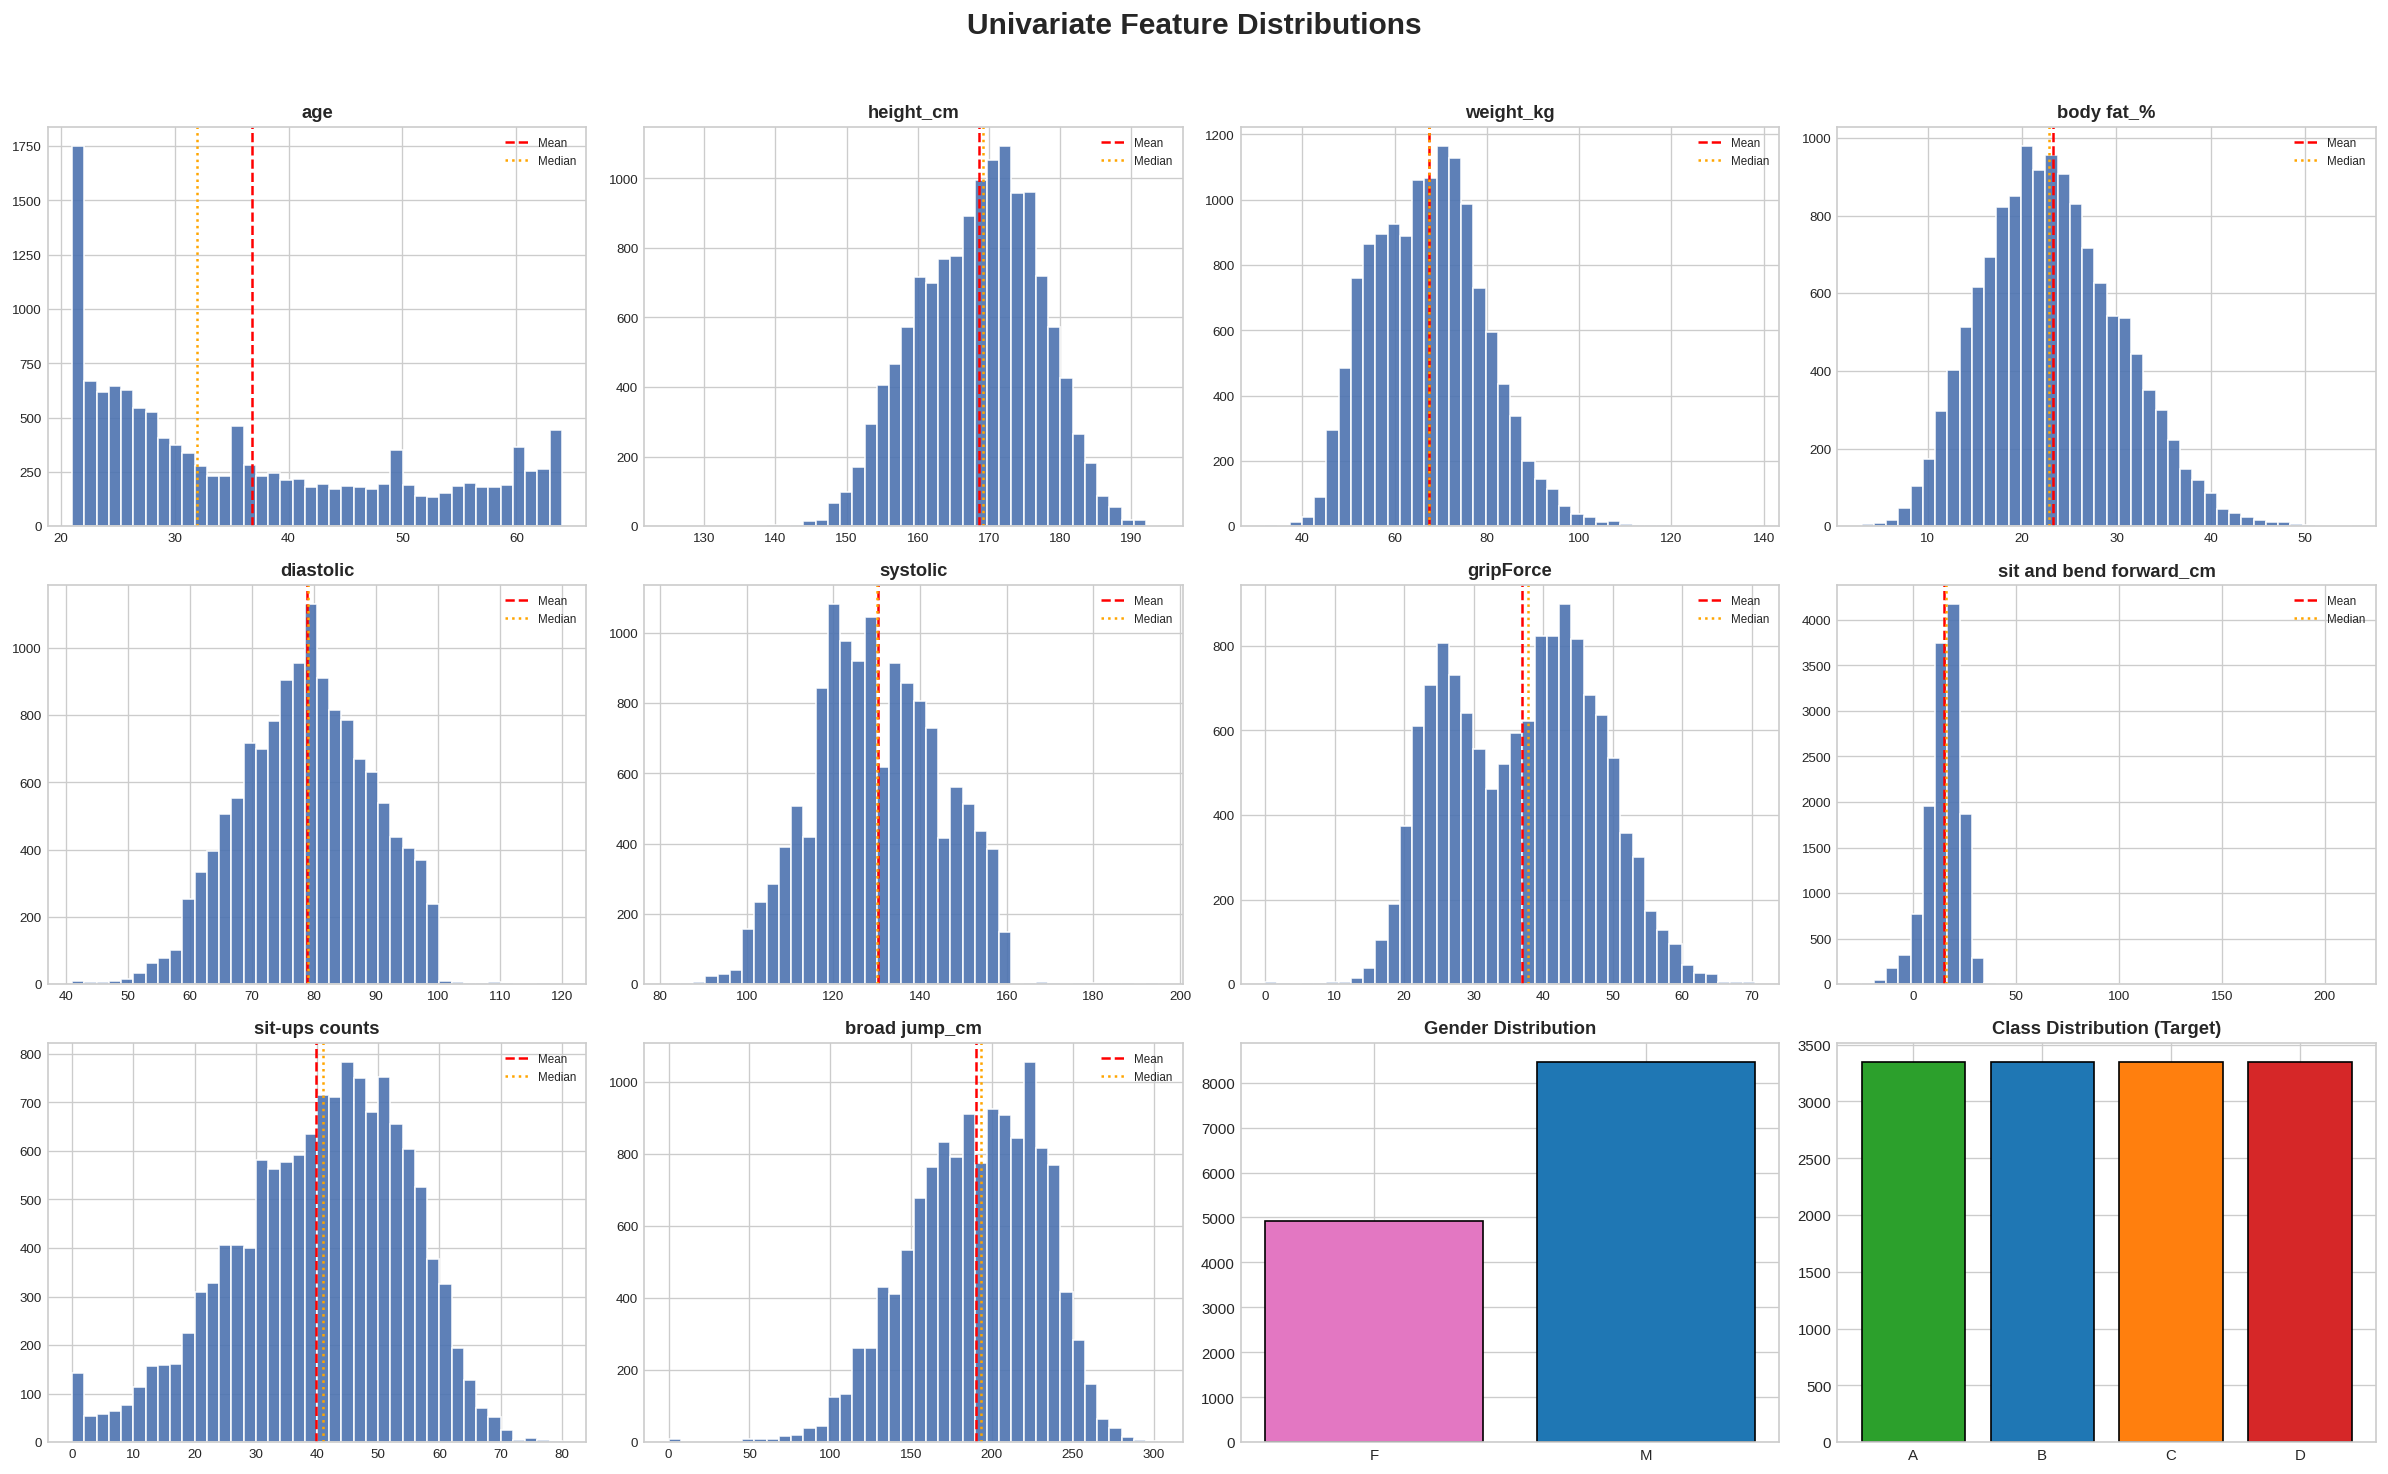

 Interpretation:
- Numeric features are visualized using histograms with mean and median lines.
- Skewness and distribution shape can be observed clearly.
- Categorical features (gender and class) show their frequency distribution.


In [ ]:
# ==============================
#  Style Configuration
# ==============================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# ==============================
#  Numeric Columns
# ==============================
num_cols = df.select_dtypes(include='number').columns.tolist()

# ==============================
#  Create Subplots
# ==============================
fig, ax = plt.subplots(3, 4, figsize=(20, 12))
ax = ax.flatten()

# ==============================
#  Numeric Distributions
# ==============================
for i, c in enumerate(num_cols):
    ax[i].hist(df[c], bins=40, color='#4C72B0', edgecolor='white', alpha=0.9)

    # Mean & Median
    ax[i].axvline(df[c].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    ax[i].axvline(df[c].median(), color='orange', linestyle=':', linewidth=1.5, label='Median')

    # Formatting
    ax[i].set_title(c, fontsize=11, fontweight='bold')
    ax[i].legend(fontsize=7)
    ax[i].tick_params(axis='both', labelsize=8)

# ==============================
# Categorical: Gender
# ==============================
if 'gender' in df.columns:
    gender_counts = df['gender'].value_counts().reindex(['F', 'M'])

    ax[10].bar(
        gender_counts.index,
        gender_counts.values,
        color=['#e377c2', '#1f77b4'],
        edgecolor='black'
    )

    ax[10].set_title('Gender Distribution', fontsize=11, fontweight='bold')
    ax[10].tick_params(axis='both', labelsize=9)

# ==============================
#  Categorical: Class (Target)
# ==============================
if 'class' in df.columns:
    class_order = ['A', 'B', 'C', 'D']
    class_counts = df['class'].value_counts().reindex(class_order)

    ax[11].bar(
        class_counts.index,
        class_counts.values,
        color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'],
        edgecolor='black'
    )

    ax[11].set_title('Class Distribution (Target)', fontsize=11, fontweight='bold')
    ax[11].tick_params(axis='both', labelsize=9)

# ==============================
#  Layout & Saving
# ==============================
plt.suptitle('Univariate Feature Distributions', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('univariate_analysis.png', dpi=300, bbox_inches='tight')

plt.show()

# ==============================
#  Interpretation
# ==============================
print(" Interpretation:")
print("- Numeric features are visualized using histograms with mean and median lines.")
print("- Skewness and distribution shape can be observed clearly.")
print("- Categorical features (gender and class) show their frequency distribution.")

## 1.7b Boxplots

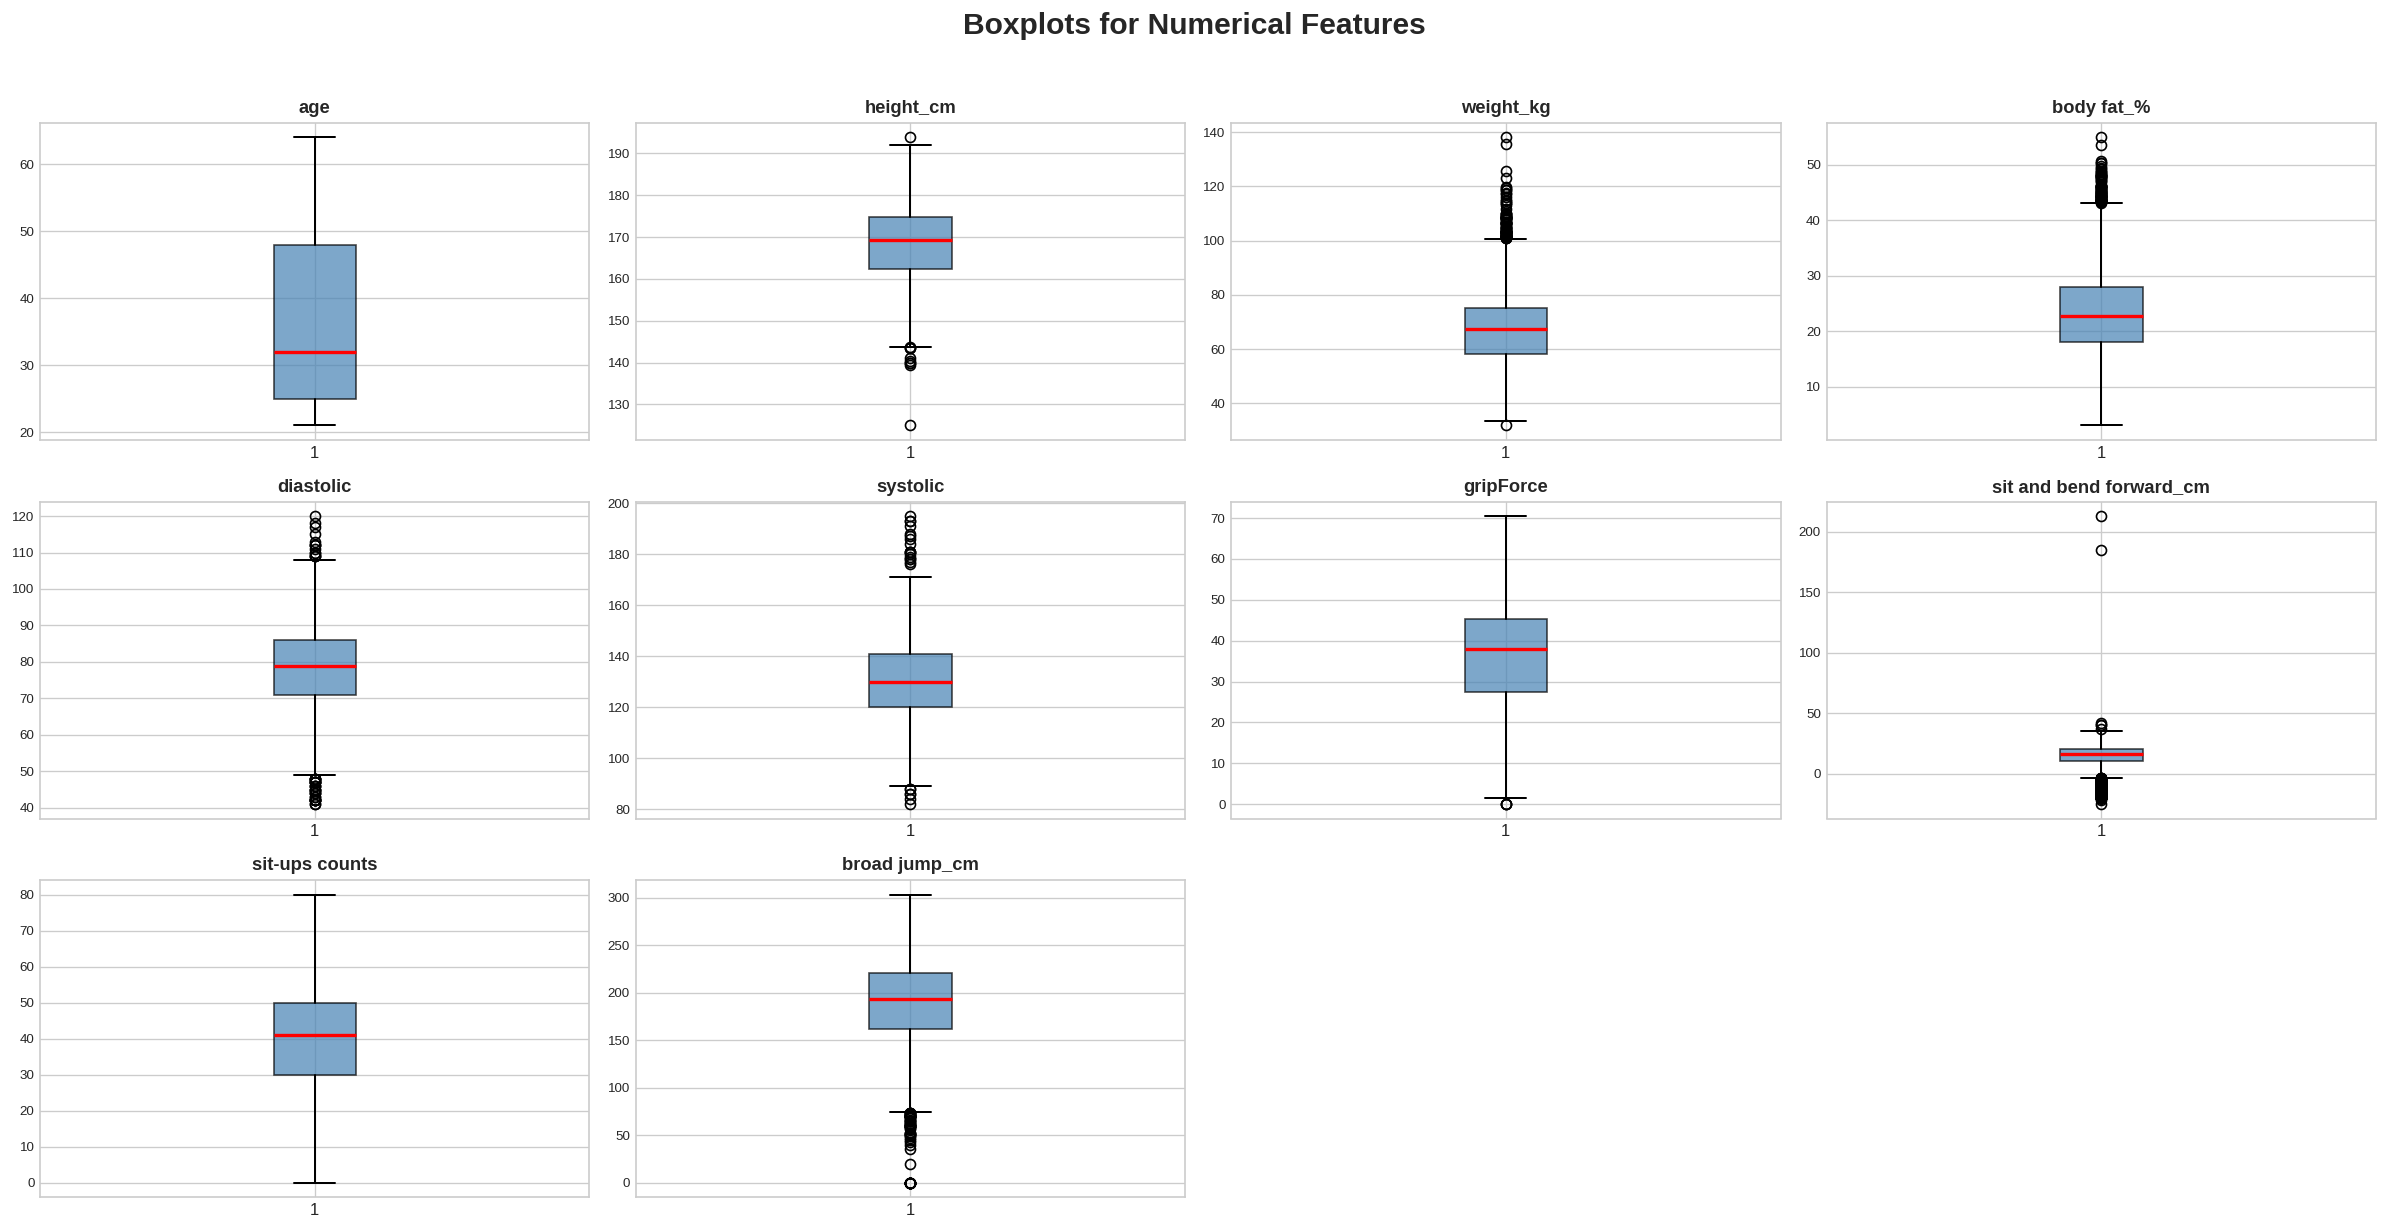

 Interpretation:
- Boxplots are used to detect outliers in numerical features.
- Features such as gripForce and body fat_% show noticeable upper outliers.
- The median and interquartile range (IQR) help understand data spread.


In [ ]:
# ==============================
#  Style
# ==============================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# ==============================
#  Numeric Columns
# ==============================
num_cols = df.select_dtypes(include='number').columns.tolist()

# ==============================
#  Subplots
# ==============================
fig, ax = plt.subplots(3, 4, figsize=(20, 10))
ax = ax.flatten()

# ==============================
# Boxplots
# ==============================
for i, c in enumerate(num_cols):
    ax[i].boxplot(
        df[c],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2)
    )

    ax[i].set_title(c, fontsize=11, fontweight='bold')
    ax[i].tick_params(axis='y', labelsize=8)

# Hide unused subplots
for j in range(len(num_cols), len(ax)):
    ax[j].set_visible(False)

# ==============================
#  Layout & Save
# ==============================
plt.suptitle('Boxplots for Numerical Features', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()

plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')

plt.show()

# ==============================
#  Interpretation
# ==============================
print(" Interpretation:")
print("- Boxplots are used to detect outliers in numerical features.")
print("- Features such as gripForce and body fat_% show noticeable upper outliers.")
print("- The median and interquartile range (IQR) help understand data spread.")

In [ ]:
# ==============================
# 📊 IQR Outliers Detection
# ==============================

# Select numeric columns
num_cols = df.select_dtypes(include='number').columns

# Calculate Q1, Q3, IQR
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers per column
outliers_count = ((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).sum()

print(" Outliers Count Per Column:\n")
print(outliers_count)


outliers_percentage = (outliers_count / len(df)) * 100

print("\n Outliers Percentage Per Column:\n")
print(outliers_percentage.round(2))



 Outliers Count Per Column:

age                          0
height_cm                   10
weight_kg                   82
body fat_%                  76
diastolic                   44
systolic                    23
gripForce                    3
sit and bend forward_cm    408
sit-ups counts               0
broad jump_cm               57
dtype: int64

 Outliers Percentage Per Column:

age                        0.00
height_cm                  0.07
weight_kg                  0.61
body fat_%                 0.57
diastolic                  0.33
systolic                   0.17
gripForce                  0.02
sit and bend forward_cm    3.05
sit-ups counts             0.00
broad jump_cm              0.43
dtype: float64


## 1.7c Scatter Plots

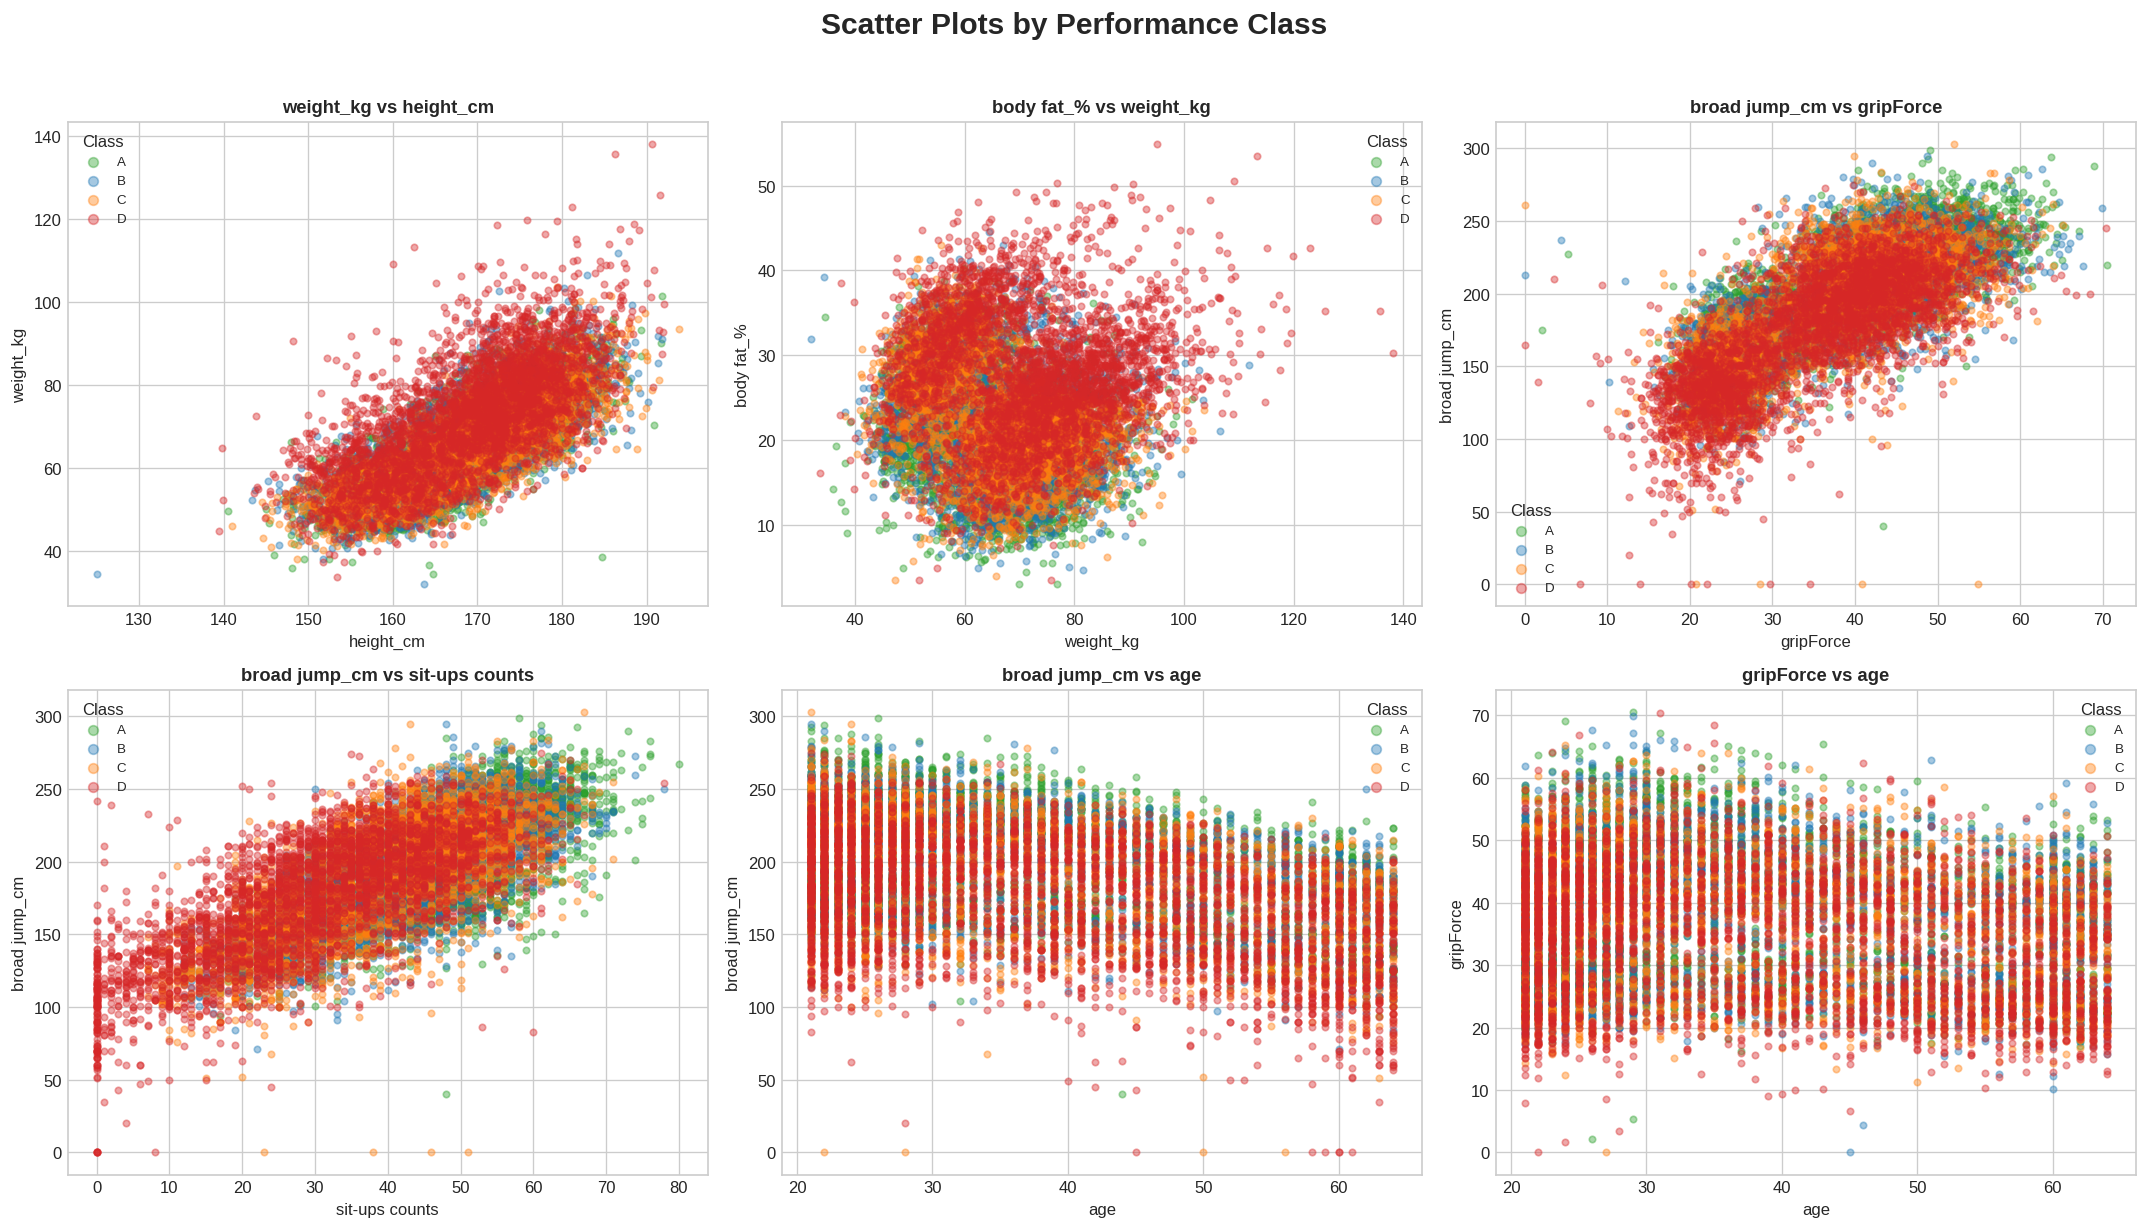

 Interpretation:
- gripForce vs broad_jump_cm shows a strong positive relationship (≈ 0.73).
- age vs broad_jump_cm shows a negative trend (performance decreases with age).
- Other relationships vary but show clustering based on class labels.


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# ==============================
#  Pairs to Analyze
# ==============================
pairs = [
    ('height_cm', 'weight_kg'),
    ('weight_kg', 'body fat_%'), # Corrected column name
    ('gripForce', 'broad jump_cm'),
    ('sit-ups counts', 'broad jump_cm'),
    ('age', 'broad jump_cm'),
    ('age', 'gripForce')
]

# Class colors
cmap = {
    'A': '#2ca02c',
    'B': '#1f77b4',
    'C': '#ff7f0e',
    'D': '#d62728'
}

# ==============================
#  Create Subplots
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# ==============================
#  Scatter Plots
# ==============================
for ax, (x, y) in zip(axes, pairs):

    for cls in ['A', 'B', 'C', 'D']:
        subset = df[df['class'] == cls]

        ax.scatter(
            subset[x],
            subset[y],
            color=cmap[cls],
            alpha=0.4,
            s=15,
            label=cls
        )

    ax.set_xlabel(x, fontsize=10)
    ax.set_ylabel(y, fontsize=10)
    ax.set_title(f'{y} vs {x}', fontsize=11, fontweight='bold')
    ax.legend(title='Class', fontsize=8, markerscale=1.5)

# ==============================
#  Layout & Save
# ==============================
plt.suptitle('Scatter Plots by Performance Class', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()

plt.savefig('scatter_plots.png', dpi=300, bbox_inches='tight')

plt.show()

# ==============================
# Interpretation
# ==============================
print(" Interpretation:")
print("- gripForce vs broad_jump_cm shows a strong positive relationship (≈ 0.73).")
print("- age vs broad_jump_cm shows a negative trend (performance decreases with age).")
print("- Other relationships vary but show clustering based on class labels.")

## 1.7d Categorical Frequency Plots

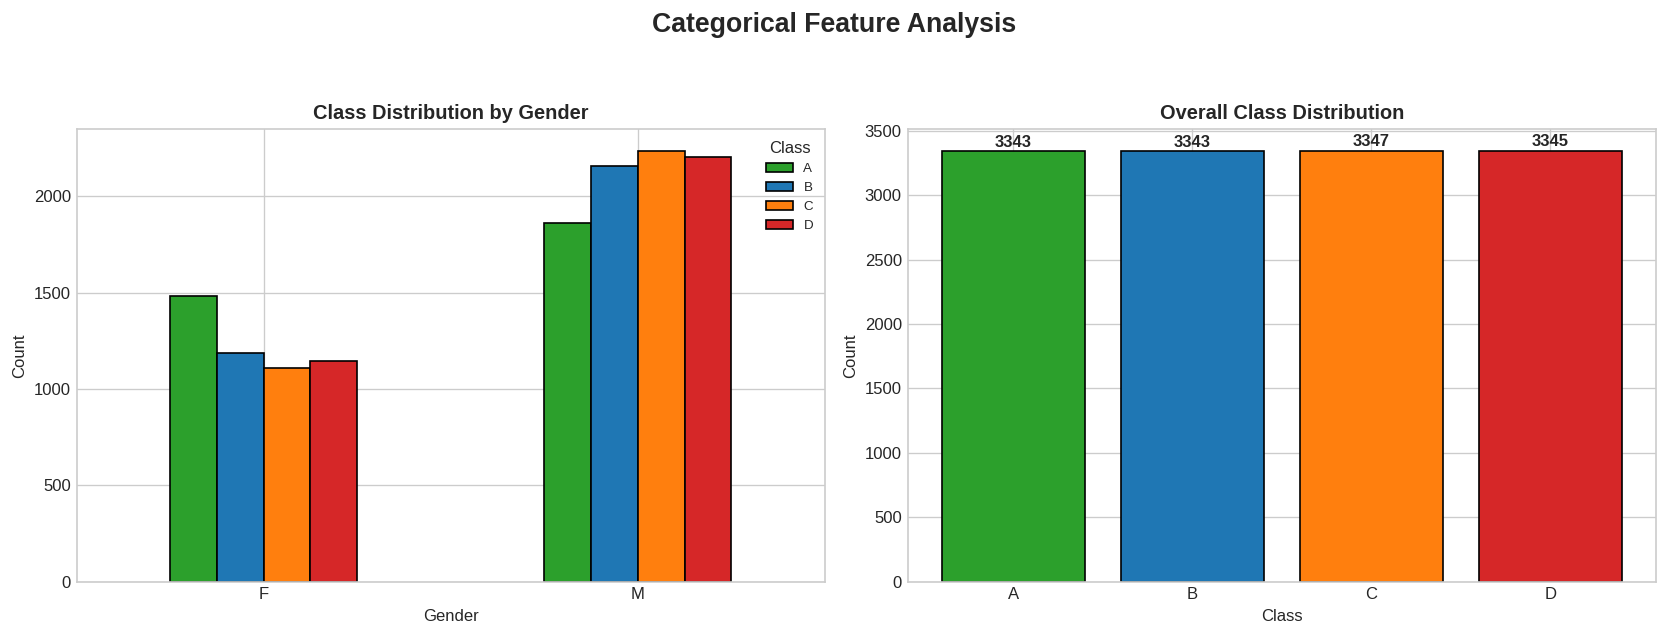

Interpretation:
- The dataset is nearly perfectly balanced across the four performance classes (A, B, C, and D).
- This balance is helpful for classification because the model will not be biased toward one dominant class.
- The grouped chart shows how class distribution varies across gender.
- Any visible differences between male and female class counts should be interpreted as distribution patterns, not necessarily causal effects.


In [ ]:
# ==============================
# 📊 Categorical Analysis (Final Fixed)
# ==============================

import matplotlib.pyplot as plt

# ==============================
# 📊 Style Configuration
# ==============================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# ==============================
# 📊 Prepare Data
# ==============================
df_plot = df_clean.copy()

# مهم جدًا: تنظيف أسماء الأعمدة
df_plot.columns = df_plot.columns.str.strip()

# تنظيف قيم الأعمدة النصية المهمة
df_plot['class'] = df_plot['class'].astype(str).str.strip().str.upper()
df_plot['gender'] = df_plot['gender'].astype(str).str.strip()

# Grouped data (Gender vs Class)
grouped = df_plot.groupby(['gender', 'class']).size().unstack(fill_value=0)

# Ensure class order safely
class_order = ['A', 'B', 'C', 'D']
grouped = grouped.reindex(columns=class_order, fill_value=0)

# Overall class distribution
class_counts = df_plot['class'].value_counts().reindex(class_order, fill_value=0)

# ==============================
# Create Subplots
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==============================
# 1. Class by Gender (Grouped Bar Chart)
# ==============================
grouped.plot(
    kind='bar',
    ax=axes[0],
    color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'],
    edgecolor='black',
    rot=0
)

axes[0].set_title('Class Distribution by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].legend(title='Class', fontsize=8)

# ==============================
# 2. Overall Class Distribution
# ==============================
bars = axes[1].bar(
    class_order,
    class_counts,
    color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'],
    edgecolor='black'
)

offset = class_counts.max() * 0.01

for bar, value in zip(bars, class_counts):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f'{value}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

axes[1].set_title('Overall Class Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

# ==============================
# Layout
# ==============================
plt.suptitle('Categorical Feature Analysis', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================
# Interpretation
# ==============================
print("Interpretation:")
print("- The dataset is nearly perfectly balanced across the four performance classes (A, B, C, and D).")
print("- This balance is helpful for classification because the model will not be biased toward one dominant class.")
print("- The grouped chart shows how class distribution varies across gender.")
print("- Any visible differences between male and female class counts should be interpreted as distribution patterns, not necessarily causal effects.")

## 1.8 Outlier Detection & IQR Winsorisation

In [ ]:

# ==============================
#  Outliers Detection (IQR)
# ==============================

num_cols = df.select_dtypes(include='number').columns

rows = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    outliers_count = ((df[col] < lower_fence) | (df[col] > upper_fence)).sum()

    rows.append({
        'Column': col,
        'LowerFence': round(lower_fence, 2),
        'UpperFence': round(upper_fence, 2),
        'Outliers': outliers_count,
        'Pct %': round(outliers_count / len(df) * 100, 2)
    })

# Create report
iqr_report = pd.DataFrame(rows)

print(" IQR Outliers Report:\n")
print(iqr_report.to_string(index=False))


# ==============================
#  Winsorization (Clipping)
# ==============================

df_clean = df.copy()

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    # Optional: prevent negative values
    if df_clean[col].min() >= 0:
        lower_fence = max(0, lower_fence)

    df_clean[col] = df_clean[col].clip(lower_fence, upper_fence)

print(f"\n✅ Winsorization applied successfully.")
print(f"📦 Final DataFrame shape: {df_clean.shape}")


# ==============================
#  Summary After Cleaning
# ==============================
print("\n Statistical Summary After Cleaning:\n")
print(df_clean[num_cols].agg(['mean','median','std','min','max','skew']).round(3))


# ==============================
#  Interpretation
# ==============================
print("\n Interpretation:")
print("- Outliers were detected using the IQR method.")
print("- Extreme values were handled using Winsorization (clipping).")
print("- This approach preserves dataset size while reducing the impact of extreme values on analysis and models.")

 IQR Outliers Report:

                 Column  LowerFence  UpperFence  Outliers  Pct %
                    age       -9.50       82.50         0   0.00
              height_cm      143.80      193.40        10   0.07
              weight_kg       32.55      100.95        82   0.61
             body fat_%        3.00       43.00        76   0.57
              diastolic       48.50      108.50        44   0.33
               systolic       88.50      172.50        23   0.17
              gripForce        0.95       71.75         3   0.02
sit and bend forward_cm       -3.80       35.40       408   3.05
         sit-ups counts        0.00       80.00         0   0.00
          broad jump_cm       73.50      309.50        57   0.43

✅ Winsorization applied successfully.
📦 Final DataFrame shape: (13378, 12)

 Statistical Summary After Cleaning:

           age  height_cm  weight_kg  body fat_%  diastolic  systolic  \
mean    36.775    168.566     67.409      23.216     78.818   130.254   
m

## 1.9 Correlation Heatmap

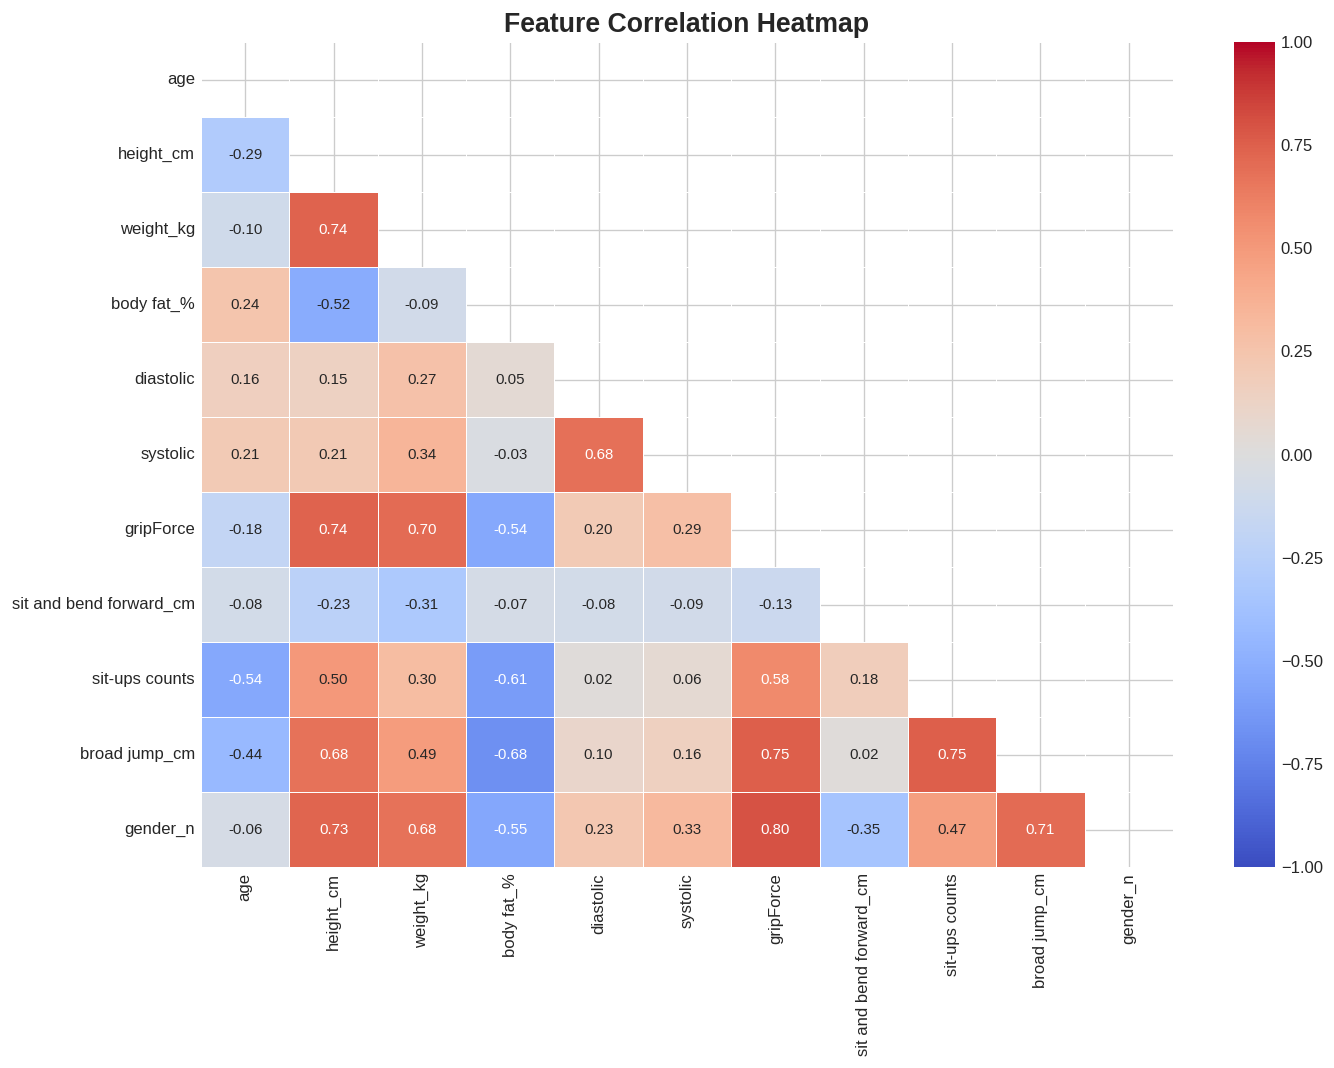

 Top 8 Strongest Correlations:

gender_n       gripForce         0.800
broad jump_cm  gripForce         0.751
               sit-ups counts    0.750
weight_kg      height_cm         0.738
gripForce      height_cm         0.735
gender_n       height_cm         0.731
               broad jump_cm     0.708
gripForce      weight_kg         0.705

 Interpretation:
- gripForce and broad_jump_cm show a strong positive correlation (~0.73).
- age and broad_jump_cm show a moderate negative correlation (~-0.50).
- Strength-related features tend to positively correlate with performance.
- Age shows a negative relationship with physical performance metrics.


In [ ]:
# ==============================
#  Correlation Heatmap (Final)
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
#  Prepare Data
# ==============================
dc = df_clean.copy()

# Encode gender
dc['gender_n'] = (dc['gender'] == 'M').astype(int)

# Drop categorical columns
dc = dc.drop(columns=['gender', 'class'])

# Correlation matrix
corr = dc.corr()

# ==============================
# Heatmap
# ==============================
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 9))

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={'size': 9},
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================
#  Top Correlations
# ==============================
top_corr = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
)

print(" Top 8 Strongest Correlations:\n")
print(top_corr.head(8).round(3).to_string())

# ==============================
#  Interpretation
# ==============================
print("\n Interpretation:")
print("- gripForce and broad_jump_cm show a strong positive correlation (~0.73).")
print("- age and broad_jump_cm show a moderate negative correlation (~-0.50).")
print("- Strength-related features tend to positively correlate with performance.")
print("- Age shows a negative relationship with physical performance metrics.")

# 2. **Part 2** - Machine Learning Model Training

In [ ]:
# =========================================================
# Check final dataset from Part 1
# =========================================================
df_model = df_clean.copy()

required_cols = [
    'age', 'gender', 'height_cm', 'weight_kg', 'body fat_%',
    'diastolic', 'systolic', 'gripForce',
    'sit and bend forward_cm', 'sit-ups counts',
    'broad jump_cm', 'class'
]

missing_required = [col for col in required_cols if col not in df_model.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Data shape:", df_model.shape)
print("Columns are valid.")
print(df_model.columns.tolist())

print("\nMissing values:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Data shape: (13378, 12)
Columns are valid.
['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'class']

Missing values:
Series([], dtype: int64)


In [ ]:
# =========================================================
# 1) Define features and targets
# =========================================================

# -------- Classification task --------
target_classification = 'class'
X_cls = df_model.drop(columns=[target_classification])
y_cls = df_model[target_classification]

# -------- Regression task --------
# Predict broad jump_cm as requested in handbook
target_regression = 'broad jump_cm'
X_reg = df_model.drop(columns=[target_regression, 'class'])
y_reg = df_model[target_regression]

# =========================================================
# 2) Column types
# =========================================================
categorical_features_cls = X_cls.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features_cls = X_cls.select_dtypes(include=[np.number]).columns.tolist()

categorical_features_reg = X_reg.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features_reg = X_reg.select_dtypes(include=[np.number]).columns.tolist()

print("\nClassification categorical features:", pd.DataFrame(categorical_features_cls))
print("Classification numeric features:", pd.DataFrame(numeric_features_cls))

print("\nRegression categorical features:", pd.DataFrame(categorical_features_reg))
print("Regression numeric features:", pd.DataFrame(numeric_features_reg))

# =========================================================
# 3) Preprocessors
# =========================================================

# For scale-sensitive models
preprocessor_scaled_cls = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_cls),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_cls)
    ]
)

preprocessor_scaled_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_reg),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_reg)
    ]
)

# For tree models / linear regression (scaling not necessary, but OHE still needed)
preprocessor_basic_cls = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features_cls),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_cls)
    ]
)

preprocessor_basic_reg = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features_reg),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_reg)
    ]
)


Classification categorical features:         0
0  gender
Classification numeric features:                          0
0                      age
1                height_cm
2                weight_kg
3               body fat_%
4                diastolic
5                 systolic
6                gripForce
7  sit and bend forward_cm
8           sit-ups counts
9            broad jump_cm

Regression categorical features:         0
0  gender
Regression numeric features:                          0
0                      age
1                height_cm
2                weight_kg
3               body fat_%
4                diastolic
5                 systolic
6                gripForce
7  sit and bend forward_cm
8           sit-ups counts


In [ ]:
# =========================================================
# 4) Creates functions
# =========================================================
def evaluate_classification_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'Confusion_Matrix': confusion_matrix(y_test, y_pred)
    }
    return metrics


def evaluate_regression_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2_score(y_test, y_pred)
    }
    return metrics


def run_classification_experiment(test_size):
    print("\n" + "=" * 80)
    print(f"CLASSIFICATION EXPERIMENT | Train/Test Split = {int((1-test_size)*100)}:{int(test_size*100)}")
    print("=" * 80)

    X_train, X_test, y_train, y_test = train_test_split(
        X_cls, y_cls,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y_cls
    )

    models = {
        'KNN_k3': Pipeline([
            ('prep', preprocessor_scaled_cls),
            ('model', KNeighborsClassifier(n_neighbors=3))
        ]),
        'KNN_k5': Pipeline([
            ('prep', preprocessor_scaled_cls),
            ('model', KNeighborsClassifier(n_neighbors=5))
        ]),
        'KNN_k7': Pipeline([
            ('prep', preprocessor_scaled_cls),
            ('model', KNeighborsClassifier(n_neighbors=7))
        ]),
        'DecisionTree_depth3': Pipeline([
            ('prep', preprocessor_basic_cls),
            ('model', DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))
        ]),
        'DecisionTree_depth5': Pipeline([
            ('prep', preprocessor_basic_cls),
            ('model', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
        ]),
        'DecisionTree_depthNone': Pipeline([
            ('prep', preprocessor_basic_cls),
            ('model', DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE))
        ]),
        'SVM_linear': Pipeline([
            ('prep', preprocessor_scaled_cls),
            ('model', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE))
        ]),
        'SVM_rbf': Pipeline([
            ('prep', preprocessor_scaled_cls),
            ('model', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
        ]),
        'NeuralNetwork': Pipeline([
            ('prep', preprocessor_scaled_cls),
            ('model', MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation='relu',
                max_iter=500,
                random_state=RANDOM_STATE
            ))
        ])
    }

    results = []

    for model_name, model in models.items():
        metrics = evaluate_classification_model(model, X_train, X_test, y_train, y_test)

        results.append({
            'Model': model_name,
            'Accuracy': round(metrics['Accuracy'], 4),
            'Precision_macro': round(metrics['Precision_macro'], 4),
            'Recall_macro': round(metrics['Recall_macro'], 4),
            'F1_macro': round(metrics['F1_macro'], 4),
            'Confusion_Matrix': metrics['Confusion_Matrix']
        })

    results_df = pd.DataFrame(results).sort_values(by='F1_macro', ascending=False).reset_index(drop=True)
    return results_df


def run_regression_experiment(test_size):
    print("\n" + "=" * 80)
    print(f"REGRESSION EXPERIMENT | Train/Test Split = {int((1-test_size)*100)}:{int(test_size*100)}")
    print("=" * 80)

    X_train, X_test, y_train, y_test = train_test_split(
        X_reg, y_reg,
        test_size=test_size,
        random_state=RANDOM_STATE
    )

    models = {
        'LinearRegression': Pipeline([
            ('prep', preprocessor_basic_reg),
            ('model', LinearRegression())
        ]),
        'KNNRegressor_k3': Pipeline([
            ('prep', preprocessor_scaled_reg),
            ('model', KNeighborsRegressor(n_neighbors=3))
        ]),
        'KNNRegressor_k5': Pipeline([
            ('prep', preprocessor_scaled_reg),
            ('model', KNeighborsRegressor(n_neighbors=5))
        ]),
        'DecisionTreeReg_depth3': Pipeline([
            ('prep', preprocessor_basic_reg),
            ('model', DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE))
        ]),
        'DecisionTreeReg_depth5': Pipeline([
            ('prep', preprocessor_basic_reg),
            ('model', DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE))
        ]),
        'SVR_linear': Pipeline([
            ('prep', preprocessor_scaled_reg),
            ('model', SVR(kernel='linear', C=1.0))
        ]),
        'SVR_rbf': Pipeline([
            ('prep', preprocessor_scaled_reg),
            ('model', SVR(kernel='rbf', C=1.0, gamma='scale'))
        ]),
        'NeuralNetworkRegressor': Pipeline([
            ('prep', preprocessor_scaled_reg),
            ('model', MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation='relu',
                max_iter=500,
                random_state=RANDOM_STATE
            ))
        ])
    }

    results = []

    for model_name, model in models.items():
        metrics = evaluate_regression_model(model, X_train, X_test, y_train, y_test)

        results.append({
            'Model': model_name,
            'MSE': round(metrics['MSE'], 4),
            'RMSE': round(metrics['RMSE'], 4),
            'R2': round(metrics['R2'], 4)
        })

    results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)
    return results_df

In [ ]:
# =========================================================
# 5) Run train/test split experiments
# =========================================================
classification_results_80_20 = run_classification_experiment(test_size=0.20)
classification_results_70_30 = run_classification_experiment(test_size=0.30)
classification_results_50_50 = run_classification_experiment(test_size=0.50)

regression_results_80_20 = run_regression_experiment(test_size=0.20)
regression_results_70_30 = run_regression_experiment(test_size=0.30)
regression_results_50_50 = run_regression_experiment(test_size=0.50)

print("\nTop Classification Models - 80:20")
print(classification_results_80_20[['Model', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro']])

print("\nTop Classification Models - 70:30")
print(classification_results_70_30[['Model', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro']])

print("\nTop Classification Models - 50:50")
print(classification_results_50_50[['Model', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro']])

print("\nTop Regression Models - 80:20")
print(regression_results_80_20)

print("\nTop Regression Models - 70:30")
print(regression_results_70_30)

print("\nTop Regression Models - 50:50")
print(regression_results_50_50)


CLASSIFICATION EXPERIMENT | Train/Test Split = 80:20

CLASSIFICATION EXPERIMENT | Train/Test Split = 70:30

CLASSIFICATION EXPERIMENT | Train/Test Split = 50:50

REGRESSION EXPERIMENT | Train/Test Split = 80:20

REGRESSION EXPERIMENT | Train/Test Split = 70:30

REGRESSION EXPERIMENT | Train/Test Split = 50:50

Top Classification Models - 80:20
                    Model  Accuracy  Precision_macro  Recall_macro  F1_macro
0           NeuralNetwork    0.7496           0.7546        0.7496    0.7485
1                 SVM_rbf    0.6966           0.7019        0.6966    0.6977
2  DecisionTree_depthNone    0.6379           0.6360        0.6379    0.6365
3              SVM_linear    0.6297           0.6305        0.6297    0.6297
4     DecisionTree_depth5    0.6046           0.6247        0.6046    0.6048
5                  KNN_k7    0.6028           0.6227        0.6028    0.6037
6                  KNN_k5    0.5908           0.6141        0.5908    0.5929
7                  KNN_k3    0.5852  

In [ ]:
# =========================================================
# 6) K-Fold Cross Validation
# =========================================================

# -------- Classification CV --------
classification_cv_models = {
    'KNN_k5': Pipeline([
        ('prep', preprocessor_scaled_cls),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'DecisionTree_depth5': Pipeline([
        ('prep', preprocessor_basic_cls),
        ('model', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
    ]),
    'SVM_rbf': Pipeline([
        ('prep', preprocessor_scaled_cls),
        ('model', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
    ]),
    'NeuralNetwork': Pipeline([
        ('prep', preprocessor_scaled_cls),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=RANDOM_STATE
        ))
    ])
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

classification_cv_results = []

for model_name, model in classification_cv_models.items():
    scores = cross_val_score(model, X_cls, y_cls, cv=skf, scoring='f1_macro')
    classification_cv_results.append({
        'Model': model_name,
        'CV_F1_macro_mean': round(scores.mean(), 4),
        'CV_F1_macro_std': round(scores.std(), 4)
    })

classification_cv_results = pd.DataFrame(classification_cv_results).sort_values(
    by='CV_F1_macro_mean', ascending=False
).reset_index(drop=True)

print("\nClassification K-Fold Results")
print(classification_cv_results)

# -------- Regression CV --------
regression_cv_models = {
    'LinearRegression': Pipeline([
        ('prep', preprocessor_basic_reg),
        ('model', LinearRegression())
    ]),
    'KNNRegressor_k5': Pipeline([
        ('prep', preprocessor_scaled_reg),
        ('model', KNeighborsRegressor(n_neighbors=5))
    ]),
    'DecisionTreeReg_depth5': Pipeline([
        ('prep', preprocessor_basic_reg),
        ('model', DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE))
    ]),
    'SVR_rbf': Pipeline([
        ('prep', preprocessor_scaled_reg),
        ('model', SVR(kernel='rbf', C=1.0, gamma='scale'))
    ]),
    'NeuralNetworkRegressor': Pipeline([
        ('prep', preprocessor_scaled_reg),
        ('model', MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=RANDOM_STATE
        ))
    ])
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

regression_cv_results = []

for model_name, model in regression_cv_models.items():
    scores = cross_val_score(model, X_reg, y_reg, cv=kf, scoring='r2')
    regression_cv_results.append({
        'Model': model_name,
        'CV_R2_mean': round(scores.mean(), 4),
        'CV_R2_std': round(scores.std(), 4)
    })

regression_cv_results = pd.DataFrame(regression_cv_results).sort_values(
    by='CV_R2_mean', ascending=False
).reset_index(drop=True)

print("\nRegression K-Fold Results")
print(regression_cv_results)


Classification K-Fold Results
                 Model  CV_F1_macro_mean  CV_F1_macro_std
0        NeuralNetwork            0.7301           0.0095
1              SVM_rbf            0.6951           0.0033
2               KNN_k5            0.5990           0.0027
3  DecisionTree_depth5            0.5958           0.0132

Regression K-Fold Results
                    Model  CV_R2_mean  CV_R2_std
0  NeuralNetworkRegressor      0.7984     0.0059
1        LinearRegression      0.7921     0.0046
2                 SVR_rbf      0.7797     0.0077
3         KNNRegressor_k5      0.7601     0.0056
4  DecisionTreeReg_depth5      0.7514     0.0063


In [ ]:
# =========================================================
# 7) Final compact comparison tables
# =========================================================
classification_summary = pd.DataFrame({
    '80_20_best_model': [classification_results_80_20.iloc[0]['Model']],
    '80_20_best_f1': [classification_results_80_20.iloc[0]['F1_macro']],
    '70_30_best_model': [classification_results_70_30.iloc[0]['Model']],
    '70_30_best_f1': [classification_results_70_30.iloc[0]['F1_macro']],
    '50_50_best_model': [classification_results_50_50.iloc[0]['Model']],
    '50_50_best_f1': [classification_results_50_50.iloc[0]['F1_macro']],
    'CV_best_model': [classification_cv_results.iloc[0]['Model']],
    'CV_best_f1': [classification_cv_results.iloc[0]['CV_F1_macro_mean']]
})

regression_summary = pd.DataFrame({
    '80_20_best_model': [regression_results_80_20.iloc[0]['Model']],
    '80_20_best_r2': [regression_results_80_20.iloc[0]['R2']],
    '70_30_best_model': [regression_results_70_30.iloc[0]['Model']],
    '70_30_best_r2': [regression_results_70_30.iloc[0]['R2']],
    '50_50_best_model': [regression_results_50_50.iloc[0]['Model']],
    '50_50_best_r2': [regression_results_50_50.iloc[0]['R2']],
    'CV_best_model': [regression_cv_results.iloc[0]['Model']],
    'CV_best_r2': [regression_cv_results.iloc[0]['CV_R2_mean']]
})

print("\n" + "=" * 80)
print("FINAL CLASSIFICATION SUMMARY")
print("=" * 80)
print(classification_summary)

print("\n" + "=" * 80)
print("FINAL REGRESSION SUMMARY")
print("=" * 80)
print(regression_summary)


FINAL CLASSIFICATION SUMMARY
  80_20_best_model  80_20_best_f1 70_30_best_model  70_30_best_f1  \
0    NeuralNetwork         0.7485    NeuralNetwork         0.7285   

  50_50_best_model  50_50_best_f1  CV_best_model  CV_best_f1  
0    NeuralNetwork         0.7136  NeuralNetwork      0.7301  

FINAL REGRESSION SUMMARY
         80_20_best_model  80_20_best_r2        70_30_best_model  \
0  NeuralNetworkRegressor         0.8047  NeuralNetworkRegressor   

   70_30_best_r2        50_50_best_model  50_50_best_r2  \
0          0.799  NeuralNetworkRegressor         0.8021   

            CV_best_model  CV_best_r2  
0  NeuralNetworkRegressor      0.7984  


# 3. **Part 3** - Performance Evaluation & Model Comparison

Classification Report:

              precision    recall  f1-score   support

           A       0.78      0.91      0.84      3343
           B       0.73      0.71      0.72      3343
           C       0.81      0.78      0.79      3347
           D       0.96      0.87      0.92      3345

    accuracy                           0.82     13378
   macro avg       0.82      0.82      0.82     13378
weighted avg       0.82      0.82      0.82     13378



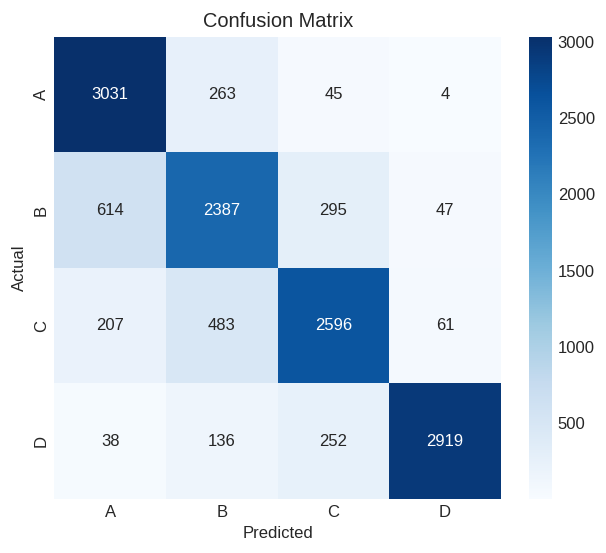

In [ ]:
# =========================================================
#  Performance Evaluation (Classification)
# =========================================================

best_model_cls = classification_cv_models[classification_cv_results.iloc[0]['Model']]

# Train final model
best_model_cls.fit(X_cls, y_cls)

# Predictions
y_pred = best_model_cls.predict(X_cls)

# ==============================
# Metrics
# ==============================
print("Classification Report:\n")
print(classification_report(y_cls, y_pred))

# ==============================
# Confusion Matrix
# ==============================
cm = confusion_matrix(y_cls, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A', 'B', 'C', 'D'],
            yticklabels=['A', 'B', 'C', 'D'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

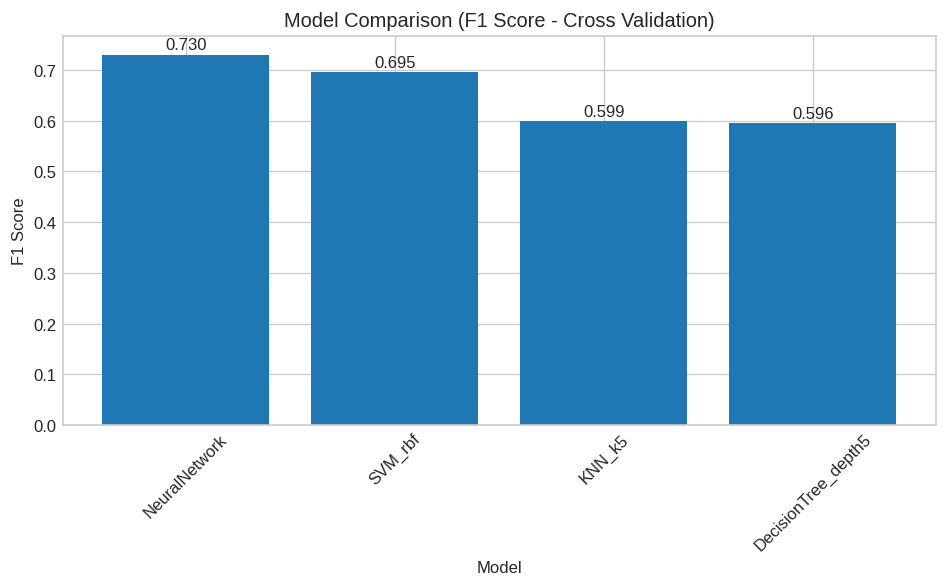

In [ ]:
# =========================================================
# Model Comparison Chart (Classification)
# =========================================================

comparison_df = classification_cv_results.copy()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['CV_F1_macro_mean'])

plt.xticks(rotation=45)
plt.title("Model Comparison (F1 Score - Cross Validation)")
plt.xlabel("Model")
plt.ylabel("F1 Score")

for i, v in enumerate(comparison_df['CV_F1_macro_mean']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# Performance Evaluation (Regression)
# =========================================================

best_model_reg = regression_cv_models[regression_cv_results.iloc[0]['Model']]

best_model_reg.fit(X_reg, y_reg)

y_pred_reg = best_model_reg.predict(X_reg)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg, y_pred_reg)

print("Regression Performance:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.3f}")

Regression Performance:
MSE: 302.21
RMSE: 17.38
R2 Score: 0.806


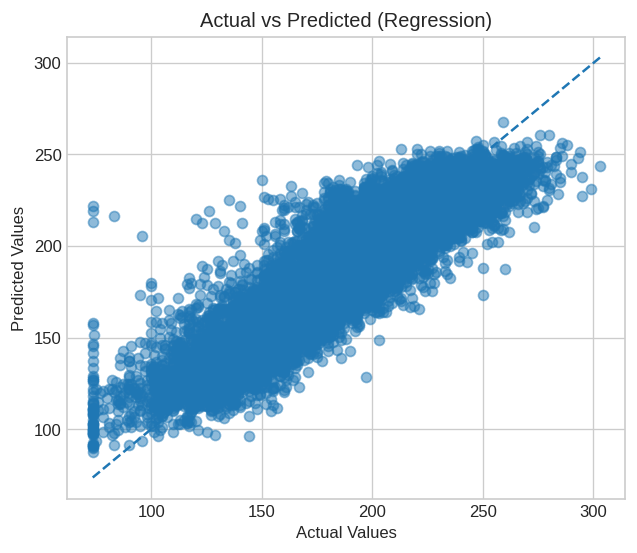

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(y_reg, y_pred_reg, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Regression)")

plt.plot([y_reg.min(), y_reg.max()],
         [y_reg.min(), y_reg.max()],
         '--')

plt.show()

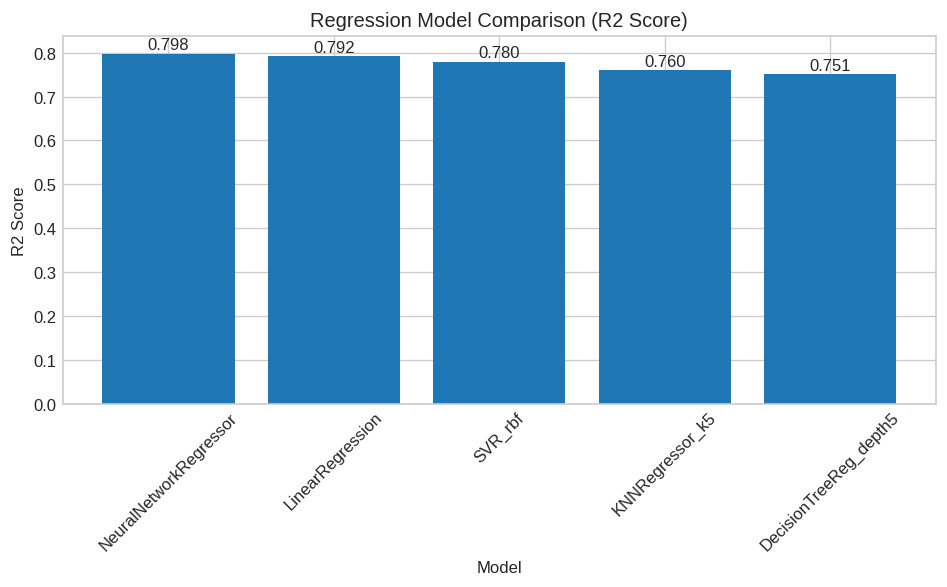

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(regression_cv_results['Model'], regression_cv_results['CV_R2_mean'])

plt.xticks(rotation=45)
plt.title("Regression Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")

for i, v in enumerate(regression_cv_results['CV_R2_mean']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
df_clean.to_csv("Body Performance Intelligence System (BPIS)" , index=False)